In [1]:
from All_Functions_transcritical import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

Solving: 100%|██████████| 100/100 [00:00<00:00, 344.97it/s]
c:\Users\Giacomo\GIACOMO\Università\Magistrale\II_Anno\Tesi\Principale\Programmi\Transcritical\All_Functions_transcritical.py:361: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Accepted polynomials: 36
--------------------------------------------------


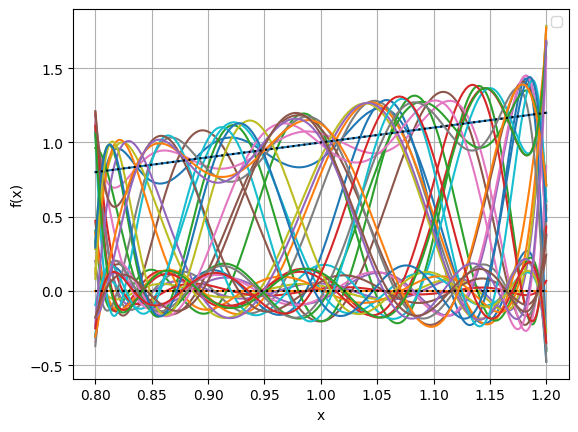

In [13]:
from All_Functions_transcritical import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

N_PC = 8

mu = sp.Rational(1, 1)

s = sp.Rational(1, 5)

solutions = []

# Build the necessary matrices and system
matrices, F, Variables = Build_matrices(N_PC)

G = Build_system(F, mu, s, Variables)

solutions = Numerical_system_solver(G, Variables, 100)

# for i in solutions:
#     print(i)
# print(len(solutions)) 

residuals = [0 for i in range(len(solutions))]

# Generate and validate the set of accepted polynomials
polynomials = Calculate_polynomials_optimized(N_PC, mu, s, solutions, residuals)
number_accepted_polynomials = len(polynomials)
print(f"Accepted polynomials: {number_accepted_polynomials}")
print("-" * 50)

# Plot the resulting polynomials
Plot_polynomials_optimized(polynomials, mu, s)

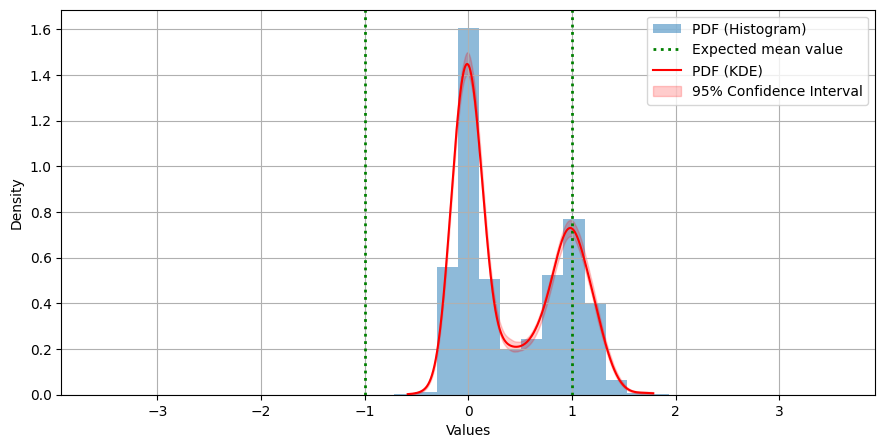

In [3]:
number_of_sampling = 101
sampling_grid = np.linspace(mu-s, mu+s, number_of_sampling)

polynomial_values = []
y = sp.symbols("y")

for pol in polynomials:
    for j in range(0, number_of_sampling):
        polynomial_values.append(pol(sampling_grid[j]))

# Determine plot range based on data
x_max = 2*max(polynomial_values)
x_min = -x_max
subdivision_number = int(x_max*10)
h = 2*x_max/subdivision_number
x_range = np.arange(x_min, x_max + float(h), float(h))

fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))

ax.hist(polynomial_values, bins=x_range, density=True, alpha=0.5, label='PDF (Histogram)')
ax.axvline(math.sqrt(mu), color='g', linestyle='dotted', linewidth=2, label="Expected mean value")
ax.axvline(-math.sqrt(mu), color='g', linestyle='dotted', linewidth=2,)

# Ensure numeric and clean
polynomial_values = np.array(polynomial_values, dtype=np.float64)
polynomial_values = polynomial_values[~np.isnan(polynomial_values)]

# KDE
kde = scp.gaussian_kde(polynomial_values)
x_min, x_max = polynomial_values.min(), polynomial_values.max()
x_kde = np.linspace(x_min, x_max, 1000)

kde_values = kde(x_kde)

# Bootstrap KDE estimates to generate a 95% confidence band
n_bootstraps = 100
bootstrap_kdes = []

for _ in range(n_bootstraps):
    sample = np.random.choice(polynomial_values, size=len(polynomial_values), replace=True)
    kde_sample = scp.gaussian_kde(sample)
    bootstrap_kdes.append(kde_sample(x_kde))

bootstrap_kdes = np.array(bootstrap_kdes)
lower = np.percentile(bootstrap_kdes, 2.5, axis=0)
upper = np.percentile(bootstrap_kdes, 97.5, axis=0)

# Plot KDE and fill in the confidence interval
ax.plot(x_kde, kde_values, color='red', label='PDF (KDE)')
ax.fill_between(x_kde, lower, upper, color="red", alpha=0.2, label="95% Confidence Interval")

# Set labels, legend, and grid
ax.set_xlabel("Values")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True)

# Display the final plot
plt.show()

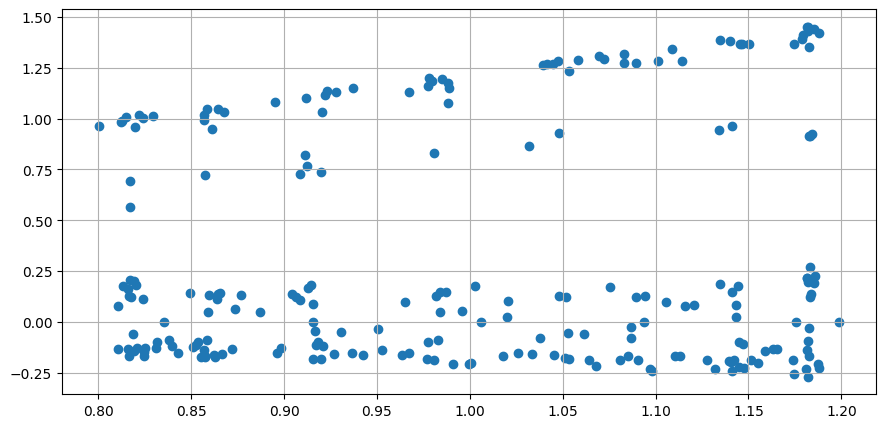

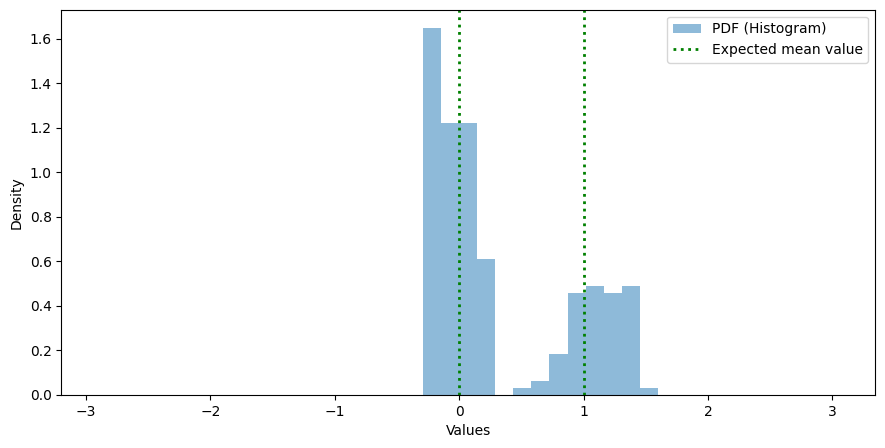

In [14]:
# Compute critical points and evaluate polynomial values at those points
polynomials_symbolic = Calculate_polynomials(N_PC, mu, s, solutions, residuals)

x_val, index = find_extrema_num(polynomials_symbolic, mu, s)
y_val = []


for j,i in enumerate(index):
    for k in range(0,len(x_val[j])):
        y_val.append(polynomials[i](float(x_val[j][k])))

x_val = [x_val[i][j] for i in range(len(x_val)) for j in range(len(x_val[i])) ]

# Scatter plot of critical values
fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))
ax.scatter(x_val, y_val)
ax.grid(True)

# Determine plot range based on data
x_max = 2 * max(y_val)
x_min = -x_max
# subdivision_number = int(x_max*10)
subdivision_number = 40
h = 2*x_max/subdivision_number
x_range = np.arange(x_min, x_max + float(h), float(h))
# Create a new plot for histogram and KDE with confidence bands
fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))

# Plot normalized histogram
ax.hist(y_val, bins=x_range, density=True, alpha=0.5, label='PDF (Histogram)')
ax.axvline(float(mu), color='g', linestyle='dotted', linewidth=2, label="Expected mean value")
ax.axvline(0, color='g', linestyle='dotted', linewidth=2,)
ax.set_xlabel("Values")
ax.set_ylabel("Density")
ax.legend()
plt.show()

[-0.07259811  1.15285801]


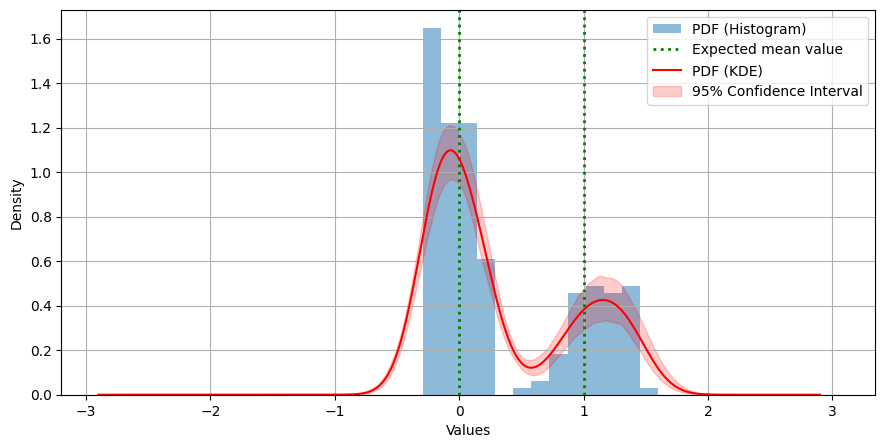

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))

ax.hist(y_val, bins=x_range, density=True, alpha=0.5, label='PDF (Histogram)')
ax.axvline(float(mu), color='g', linestyle='dotted', linewidth=2, label="Expected mean value")
ax.axvline(0, color='g', linestyle='dotted', linewidth=2,)

# Compute Kernel Density Estimate (KDE)
kde = scp.gaussian_kde(y_val)
x_kde = np.linspace(x_min, x_max, 1000)
kde_values = kde(x_kde)

from scipy.signal import find_peaks

# Find peaks
peaks_idx, _ = find_peaks(kde_values)
print(x_kde[peaks_idx])

# Bootstrap KDE estimates to generate a 95% confidence band
n_bootstraps = 100
bootstrap_kdes = []

for _ in range(n_bootstraps):
    sample = np.random.choice(y_val, size=len(y_val), replace=True)
    kde_sample = scp.gaussian_kde(sample)
    bootstrap_kdes.append(kde_sample(x_kde))

bootstrap_kdes = np.array(bootstrap_kdes)
lower = np.percentile(bootstrap_kdes, 2.5, axis=0)
upper = np.percentile(bootstrap_kdes, 97.5, axis=0)

# Plot KDE and fill in the confidence interval
ax.plot(x_kde, kde_values, color='red', label='PDF (KDE)')
ax.fill_between(x_kde, lower, upper, color="red", alpha=0.2, label="95% Confidence Interval")

# Set labels, legend, and grid
ax.set_xlabel("Values")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True)

# Display the final plot
plt.show()

Solving: 100%|██████████| 100/100 [00:00<00:00, 140.26it/s]


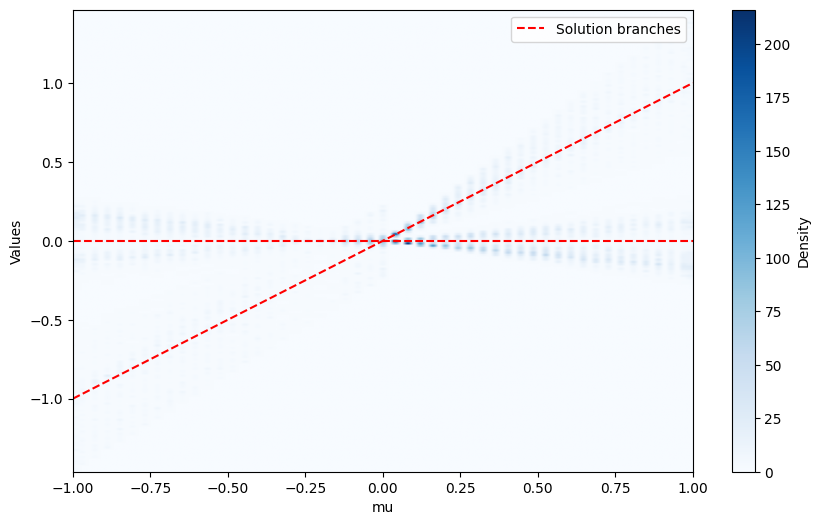

In [12]:
N_PC = 10
N_sample_mu = 50

a = sp.Rational(-1,1)       # lower bound of the interval
b = sp.Rational(1,1)        # upper bound of the interval
h = sp.Rational(b - a, N_sample_mu)

mu = np.arange(a, b + h, h)

N_sample_sigma = 1
sigma = []

for i in range(len(mu)):
    if mu[i]<=0:
        sigma.append(sp.Rational(1,5))
    else:
        sigma.append(sp.Rational(mu[i],5))

mu_values = []
branch_values = []

matrices, F, Variables = Build_matrices(N_PC)

for i in range(0, N_sample_mu + 1):
            
    H = copy.deepcopy(F)
    G = Build_system(H, mu[i], sigma[i], Variables)
        
    solutions = Numerical_system_solver(G, Variables, 100)
    residuals = [0 for i in range(len(solutions))]
    # Generate and validate the set of accepted polynomials

    polynomials = Calculate_polynomials_optimized(N_PC, mu[i], sigma[i], solutions, residuals)

    polynomials_symbolic = Calculate_polynomials(N_PC, mu[i], sigma[i], solutions, residuals)

    x_val, index = find_extrema_num(polynomials_symbolic, mu[i], sigma[i])
    y_val = []


    for l,m in enumerate(index):
        for k in range(0,len(x_val[l])):
            y_val.append(polynomials[m](float(x_val[l][k])))

    x_val = [x_val[l][m] for l in range(len(x_val)) for m in range(len(x_val[l])) ]
    mu_val = [mu[i] for l in range (len(y_val))]
    mu_values.append(mu_val)
    branch_values.append(y_val)

mu_values = [float(item) for sublist in mu_values for item in sublist]
branch_values = [float(item) for sublist in branch_values for item in sublist]

# Construction of the grid
mu_bins = np.linspace(float(a), float(b), 100)
y_bins = np.linspace(min(branch_values), max(branch_values), 200)

H, xedges, yedges = np.histogram2d(mu_values, branch_values, bins=[mu_bins, y_bins])

# Transposition, necessary for imshow
H = H.T

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Show H
im = ax.imshow(H, aspect='auto', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues')

# True Branch
ax.plot(mu_bins, mu_bins, color="red", linestyle="--", label="Solution branches")
ax.plot(mu_bins, [0 for i in range (len(mu_bins))], color="red", linestyle="--")

ax.set_xlabel('mu')
ax.set_ylabel('Values')
ax.legend()
fig.colorbar(im, ax=ax, label='Density')
plt.show()
fig.savefig(f"Plots/Bifurcation_N_PC={N_PC}_mu_samples={N_sample_mu}.png")